# 01 - Preprocessing
## Objectif : Préparer le dataset ML avec vraies valeurs contemporaines

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import clickhouse_connect
import json
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid')
print('✅ Imports OK')

✅ Imports OK


## 1. Connexion + Chargement

In [16]:
client = clickhouse_connect.get_client(
    host='clickhouse', port=8123,
    user='default', password='clickhouse123',
    database='gold'
)

df = client.query_df("""
SELECT
    d.Year                               AS year,
    d.Month                              AS month,
    d.Quarter                            AS quarter,
    SUM(f.LinePrice)                     AS total_sales,
    SUM(f.Quantity)                      AS total_quantity,
    COUNT(DISTINCT f.DocumentCode)       AS nb_documents,
    COUNT(DISTINCT f.ClientSK)           AS nb_clients
FROM gold.fact_sales AS f
JOIN gold.dim_date AS d ON f.DateSK = d.DateSK
WHERE f.DocumentTypeSK IN (4, 1, 5)
  AND f.LinePrice IS NOT NULL
GROUP BY year, month, quarter
ORDER BY year, month
""")

df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
print(f'✅ {len(df)} mois chargés — shape : {df.shape}')
df.head(10)

✅ 51 mois chargés — shape : (51, 8)


,year,month,quarter,total_sales,total_quantity,nb_documents,nb_clients,date
0,2021,3,1,404.06,6,1,1,2021-03-01
1,2022,1,1,"591,407.94",10983,1125,197,2022-01-01
2,2022,2,1,"576,097.45",10770,1263,190,2022-02-01
3,2022,3,1,"680,213.89",11488,1304,200,2022-03-01
4,2022,4,2,"650,789.55",11385,1093,224,2022-04-01
5,2022,5,2,"734,335.68",14813,1199,220,2022-05-01
6,2022,6,2,"754,273.83",12461,1280,223,2022-06-01
7,2022,7,3,"787,031.57",14561,1112,218,2022-07-01
8,2022,8,3,"847,028.15",14118,1169,213,2022-08-01
9,2022,9,3,"1,063,182.57",16459,1425,235,2022-09-01


## 2. Nettoyage — Suppression des mois incomplets

In [17]:
print(f'Avant nettoyage : {len(df)} mois')
print('Mois incomplets :')
print(df[(df['date'] < '2022-01-01') | (df['date'] >= '2026-02-01')][['date', 'total_sales']].to_string(index=False))

df = df[
    (df['date'] >= '2022-01-01') & (df['date'] < '2026-02-01')
].reset_index(drop=True)

print(f'\nAprès nettoyage : {len(df)} mois')
print(f'Période : {df["date"].min().strftime("%b %Y")} → {df["date"].max().strftime("%b %Y")}')

Avant nettoyage : 51 mois
Mois incomplets :
      date  total_sales
2021-03-01       404.06
2026-02-01   114,247.11

Après nettoyage : 49 mois
Période : Jan 2022 → Jan 2026


## 3. Feature Engineering

In [18]:
df_ml = df.copy()

# Variables temporelles
df_ml['semester']    = df_ml['month'].apply(lambda x: 1 if x <= 6 else 2)
df_ml['is_summer']   = df_ml['month'].isin([7, 8]).astype(int)
df_ml['is_end_year'] = df_ml['month'].isin([11, 12]).astype(int)
df_ml['is_january']  = (df_ml['month'] == 1).astype(int)

# Lag features
df_ml['lag_1'] = df_ml['total_sales'].shift(1)
df_ml['lag_2'] = df_ml['total_sales'].shift(2)
df_ml['lag_3'] = df_ml['total_sales'].shift(3)

# Rolling features
df_ml['rolling_mean_3'] = df_ml['total_sales'].shift(1).rolling(3).mean()
df_ml['rolling_mean_6'] = df_ml['total_sales'].shift(1).rolling(6).mean()

# lag_12 avec fallback sur moyenne mensuelle
df_ml['lag_12'] = df_ml['total_sales'].shift(12)
monthly_avg     = df_ml.groupby('month')['total_sales'].mean()
df_ml['lag_12'] = df_ml.apply(
    lambda row: monthly_avg[row['month']] if pd.isna(row['lag_12']) else row['lag_12'],
    axis=1
)

# Supprimer NaN
df_ml = df_ml.dropna().reset_index(drop=True)

print(f'✅ Dataset prêt : {df_ml.shape}')
print(f'Période : {df_ml["date"].min().strftime("%b %Y")} → {df_ml["date"].max().strftime("%b %Y")}')
df_ml.head()

✅ Dataset prêt : (43, 18)
Période : Jul 2022 → Jan 2026


,year,month,quarter,total_sales,total_quantity,nb_documents,nb_clients,date,semester,is_summer,is_end_year,is_january,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_6,lag_12
0,2022,7,3,"787,031.57",14561,1112,218,2022-07-01,2,1,0,0,"754,273.83","734,335.68","650,789.55","713,133.02","664,519.72","1,276,582.07"
1,2022,8,3,"847,028.15",14118,1169,213,2022-08-01,2,1,0,0,"787,031.57","754,273.83","734,335.68","758,547.03","697,123.66","1,189,156.28"
2,2022,9,3,"1,063,182.57",16459,1425,235,2022-09-01,2,0,0,0,"847,028.15","787,031.57","754,273.83","796,111.18","742,278.78","1,333,028.58"
3,2022,10,4,"937,241.06",15262,1214,220,2022-10-01,2,0,0,0,"1,063,182.57","847,028.15","787,031.57","899,080.76","806,106.89","1,336,445.74"
4,2022,11,4,"957,116.13",16283,1307,215,2022-11-01,2,0,1,0,"937,241.06","1,063,182.57","847,028.15","949,150.59","853,848.81","1,222,431.36"


## 4. Corrélation de toutes les variables avec total_sales

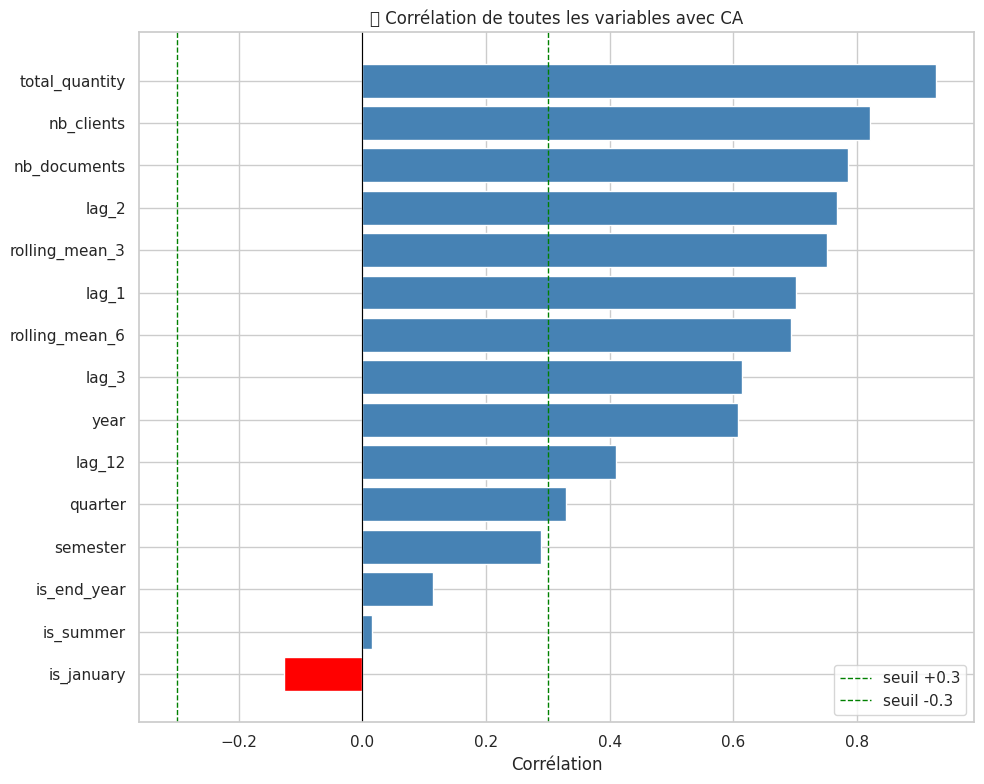


Corrélations triées :
is_january       -0.13
is_summer         0.02
is_end_year       0.12
semester          0.29
quarter           0.33
lag_12            0.41
year              0.61
lag_3             0.61
rolling_mean_6    0.69
lag_1             0.70
rolling_mean_3    0.75
lag_2             0.77
nb_documents      0.79
nb_clients        0.82
total_quantity    0.93


In [19]:
TARGET   = 'total_sales'
ALL_COLS = [c for c in df_ml.columns if c not in [TARGET, 'date', 'month']]

corr = df_ml[ALL_COLS + [TARGET]].corr()[TARGET].drop(TARGET).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['red' if v < 0 else 'steelblue' for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0,    color='black',  linewidth=0.8)
ax.axvline(0.3,  color='green',  linewidth=1, linestyle='--', label='seuil +0.3')
ax.axvline(-0.3, color='green',  linewidth=1, linestyle='--', label='seuil -0.3')
ax.set_title('📊 Corrélation de toutes les variables avec CA')
ax.set_xlabel('Corrélation')
ax.legend()
plt.tight_layout()
plt.show()

print('\nCorrélations triées :')
print(corr.to_string())

## 5. Sélection automatique du meilleur seuil (cross-validation)

In [20]:
tscv       = TimeSeriesSplit(n_splits=4)
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
results_thresh = []

for thresh in thresholds:
    selected = corr[abs(corr) > thresh].index.tolist()
    if len(selected) < 2:
        continue

    X_all = df_ml[selected]
    y_all = df_ml[TARGET]
    sc    = StandardScaler()
    X_sc  = sc.fit_transform(X_all)

    cv_scores = cross_val_score(
        LinearRegression(), X_sc, y_all,
        cv=tscv, scoring='neg_mean_absolute_error'
    )
    mae_cv = -cv_scores.mean()

    results_thresh.append({
        'threshold':   thresh,
        'nb_features': len(selected),
        'features':    selected,
        'MAE_cv':      mae_cv,
    })
    print(f'threshold={thresh} | nb_features={len(selected):>2} | MAE_cv={mae_cv:>10,.0f} DT')

df_thresh    = pd.DataFrame(results_thresh)
best_idx     = df_thresh['MAE_cv'].idxmin()
best_thresh  = df_thresh.loc[best_idx, 'threshold']
FEATURES_SEL = df_thresh.loc[best_idx, 'features']

print(f'\n🏆 Meilleur seuil : {best_thresh}')
print(f'   MAE_cv          : {df_thresh.loc[best_idx, "MAE_cv"]:,.0f} DT')
print(f'   Features ({len(FEATURES_SEL)}) : {FEATURES_SEL}')

threshold=0.1 | nb_features=14 | MAE_cv=   111,870 DT
threshold=0.2 | nb_features=12 | MAE_cv=   112,843 DT
threshold=0.3 | nb_features=11 | MAE_cv=   146,297 DT
threshold=0.4 | nb_features=10 | MAE_cv=   104,304 DT
threshold=0.5 | nb_features= 9 | MAE_cv=   103,087 DT
threshold=0.6 | nb_features= 9 | MAE_cv=   103,087 DT
threshold=0.7 | nb_features= 6 | MAE_cv=    67,539 DT

🏆 Meilleur seuil : 0.7
   MAE_cv          : 67,539 DT
   Features (6) : ['lag_1', 'rolling_mean_3', 'lag_2', 'nb_documents', 'nb_clients', 'total_quantity']


## 6. Sauvegarde

In [21]:
df_ml.to_csv('/app/notebooks/ml_dataset.csv', index=False)

with open('/app/notebooks/selected_features.json', 'w') as f:
    json.dump(list(FEATURES_SEL), f)

with open('/app/notebooks/selected_features.json', 'r') as f:
    print(f'✅ Features sauvegardées : {f.read()}')

print(f'✅ Dataset sauvegardé    : {df_ml.shape}')
print(f'   Colonnes : {list(df_ml.columns)}')

✅ Features sauvegardées : ["lag_1", "rolling_mean_3", "lag_2", "nb_documents", "nb_clients", "total_quantity"]
✅ Dataset sauvegardé    : (43, 18)
   Colonnes : ['year', 'month', 'quarter', 'total_sales', 'total_quantity', 'nb_documents', 'nb_clients', 'date', 'semester', 'is_summer', 'is_end_year', 'is_january', 'lag_1', 'lag_2', 'lag_3', 'rolling_mean_3', 'rolling_mean_6', 'lag_12']
